<a href="https://colab.research.google.com/github/don-jose07/health-risk-predictor/blob/main/BDA_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install necessary R packages
install.packages(c("sparklyr", "tidyverse", "corrplot", "gridExtra"))

# 2. Load libraries
library(sparklyr)
library(tidyverse)
library(corrplot)
library(gridExtra)

# 3. Download & Install Apache Spark inside Colab
spark_install(version = "3.5.0")

# 4. Connect to local Spark instance
sc <- spark_connect(master = "local")

# Print active Spark version
cat("Spark Connection Active:", as.character(spark_version(sc)), "\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘config’, ‘globals’



Attaching package: ‘sparklyr’


The following object is masked from ‘package:stats’:

    filter


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks sparklyr::filter(), stats::filter()
✖ purrr::invoke() masks sparklyr::invoke()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




Spark Connection Active: 3.5.0 


In [2]:
# 1. Download Pima Indians Diabetes Dataset
pima_url <- "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols <- c("Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
               "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome")

diabetes_raw <- read.csv(pima_url, header = FALSE, col.names = pima_cols)

# 2. Check for vitals.csv or create standard vitals records
if (file.exists("vitals.csv")) {
  vitals_raw <- read.csv("vitals.csv")
} else {
  set.seed(42)
  n <- nrow(diabetes_raw)
  vitals_raw <- data.frame(
    Heart_Rate        = round(rnorm(n, 78, 12)),
    Respiratory_Rate  = round(rnorm(n, 18, 4)),
    Body_Temp         = round(rnorm(n, 37.0, 0.7), 1),
    Oxygen_Saturation = pmin(100, round(rnorm(n, 97, 2.5))),
    Systolic_BP       = round(rnorm(n, 125, 15)),
    Diastolic_BP      = round(rnorm(n, 80, 10))
  )
}

# 3. Clean invalid zeros in biological measurements (Pima dataset)
zero_cols <- c("Glucose", "BloodPressure", "BMI")
diabetes_clean <- diabetes_raw %>%
  mutate(across(all_of(zero_cols), ~ ifelse(.x == 0, median(.x[.x > 0]), .x)))

# 4. Merge clean records
min_rows <- min(nrow(diabetes_clean), nrow(vitals_raw))
merged_df <- bind_cols(
  diabetes_clean[1:min_rows, c("Age", "Glucose", "BMI", "BloodPressure")],
  vitals_raw[1:min_rows, c("Heart_Rate", "Respiratory_Rate", "Body_Temp", "Oxygen_Saturation", "Systolic_BP", "Diastolic_BP")]
)

cat("Merged dataset shape:", nrow(merged_df), "rows,", ncol(merged_df), "columns\n")

Merged dataset shape: 768 rows, 10 columns


In [4]:
set.seed(42)

# 1. Feature synthesis and symptom simulation
processed_df <- merged_df %>%
  mutate(
    Sym_Chest_Pain  = as.double(rbinom(n(), 1, 0.09)),
    Sym_Breathless  = as.double(rbinom(n(), 1, 0.11)),
    Sym_High_Thirst = as.double(rbinom(n(), 1, 0.14)),
    Pulse_Pressure  = as.double(Systolic_BP - Diastolic_BP),
    MAP             = as.double(Diastolic_BP + (Pulse_Pressure / 3)),

    # Calculate clinical early warning index
    clinical_score = (Oxygen_Saturation < 94) * 2 + (Oxygen_Saturation < 90) * 2 +
                     (Heart_Rate > 100 | Heart_Rate < 55) * 1 +
                     (Respiratory_Rate > 22 | Respiratory_Rate < 10) * 2 +
                     (Systolic_BP > 140 | Systolic_BP < 95) * 1 +
                     (Body_Temp > 38.0 | Body_Temp < 35.5) * 1 +
                     (Glucose > 180) * 2 +
                     (Sym_Chest_Pain * 3) +
                     (Sym_Breathless * 2),

    # Target Class Label
    Risk_Label = case_when(
      clinical_score <= 1 ~ "Low",
      clinical_score <= 4 ~ "Medium",
      TRUE                ~ "High"
    )
  ) %>%
  select(-clinical_score)

# 2. Transfer into Apache Spark memory
spark_health_tbl <- copy_to(sc, processed_df, "spark_health_data", overwrite = TRUE)

cat("Data successfully loaded into Apache Spark.\n")

# 3. Fixed sdf_describe using character vector
sdf_describe(spark_health_tbl, cols = c("Glucose", "Oxygen_Saturation", "Systolic_BP")) %>%
  collect() %>%
  print()

Data successfully loaded into Apache Spark.
# A tibble: 5 × 4
  summary Glucose           Oxygen_Saturation Systolic_BP      
  <chr>   <chr>             <chr>             <chr>            
1 count   768               768               768              
2 mean    121.65625         96.8515625        124.78125        
3 stddev  30.43828582241516 2.289673583142428 15.06272197248357
4 min     44                89.0              78.0             
5 max     199               100.0             173.0            


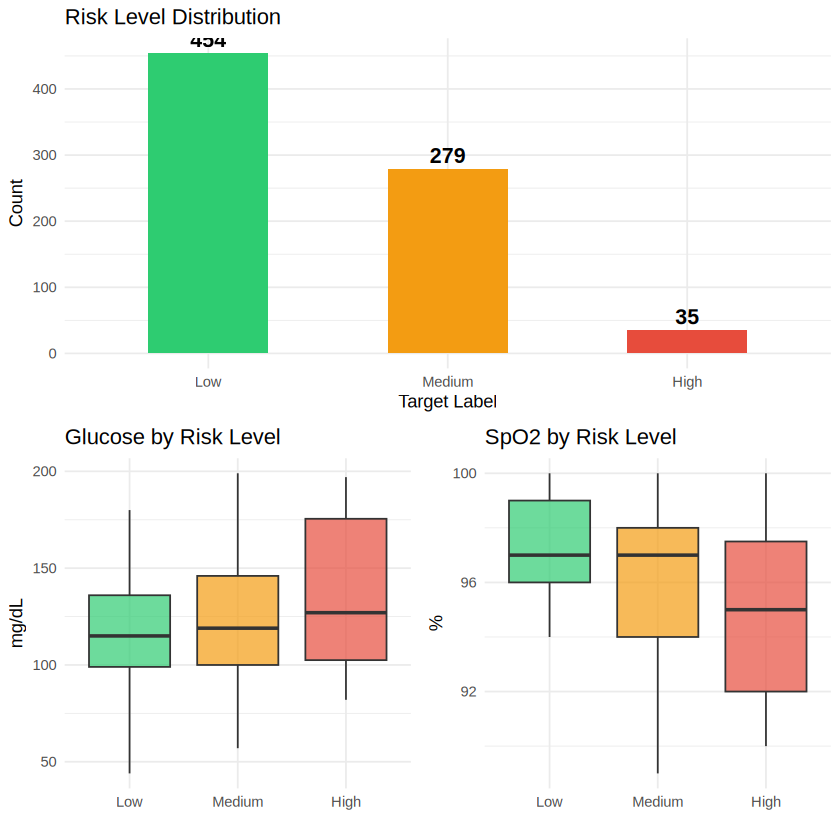

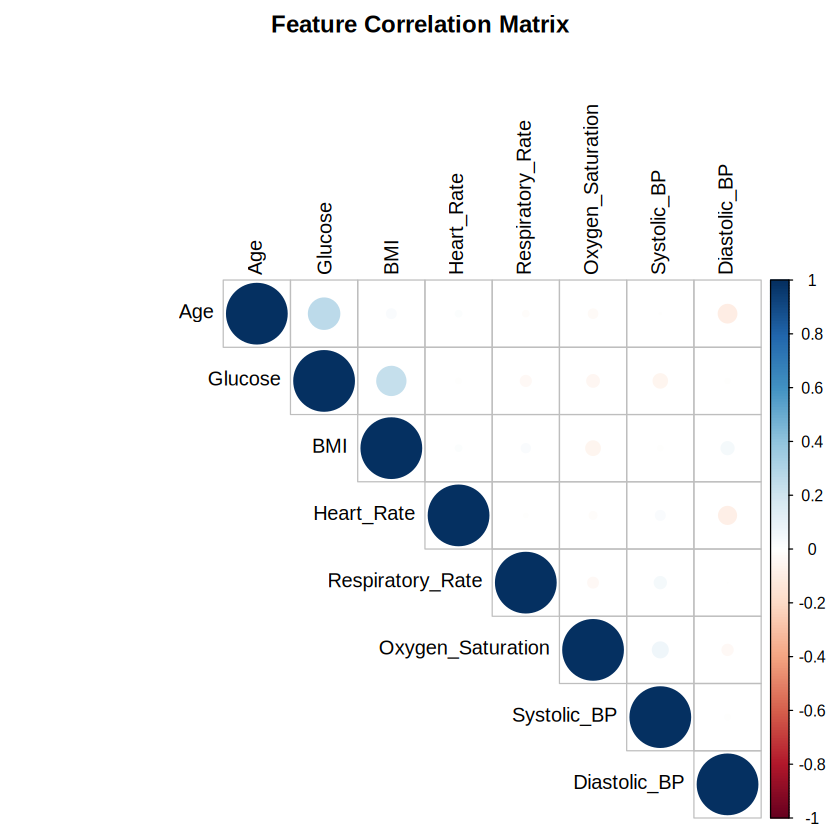

In [5]:
# 1. Class Distribution Plot
class_counts <- spark_health_tbl %>%
  group_by(Risk_Label) %>%
  count() %>%
  collect() %>%
  mutate(Risk_Label = factor(Risk_Label, levels = c("Low", "Medium", "High")))

p_dist <- ggplot(class_counts, aes(x = Risk_Label, y = n, fill = Risk_Label)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = n), vjust = -0.4, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c("Low" = "#2ecc71", "Medium" = "#f39c12", "High" = "#e74c3c")) +
  labs(title = "Risk Level Distribution", x = "Target Label", y = "Count") +
  theme_minimal()

# 2. Vitals Distributions: Glucose & SpO2
plot_data <- spark_health_tbl %>%
  select(Risk_Label, Glucose, Oxygen_Saturation) %>%
  collect() %>%
  mutate(Risk_Label = factor(Risk_Label, levels = c("Low", "Medium", "High")))

p_glucose <- ggplot(plot_data, aes(x = Risk_Label, y = Glucose, fill = Risk_Label)) +
  geom_boxplot(alpha = 0.7, show.legend = FALSE) +
  scale_fill_manual(values = c("Low" = "#2ecc71", "Medium" = "#f39c12", "High" = "#e74c3c")) +
  labs(title = "Glucose by Risk Level", y = "mg/dL", x = "") +
  theme_minimal()

p_spo2 <- ggplot(plot_data, aes(x = Risk_Label, y = Oxygen_Saturation, fill = Risk_Label)) +
  geom_boxplot(alpha = 0.7, show.legend = FALSE) +
  scale_fill_manual(values = c("Low" = "#2ecc71", "Medium" = "#f39c12", "High" = "#e74c3c")) +
  labs(title = "SpO2 by Risk Level", y = "%", x = "") +
  theme_minimal()

# Display side-by-side
grid.arrange(p_dist, p_glucose, p_spo2, layout_matrix = rbind(c(1, 1), c(2, 3)))

# 3. Correlation Heatmap
num_cols <- c("Age", "Glucose", "BMI", "Heart_Rate", "Respiratory_Rate", "Oxygen_Saturation", "Systolic_BP", "Diastolic_BP")
corr_mat <- cor(spark_health_tbl %>% select(all_of(num_cols)) %>% collect())
corrplot(corr_mat, method = "circle", type = "upper", tl.col = "black", title = "Feature Correlation Matrix", mar = c(0, 0, 2, 0))

In [8]:
# 1. Define feature columns
feature_columns <- c(
  "Age", "Glucose", "BMI", "BloodPressure", "Heart_Rate",
  "Respiratory_Rate", "Body_Temp", "Oxygen_Saturation",
  "Systolic_BP", "Diastolic_BP", "Pulse_Pressure", "MAP",
  "Sym_Chest_Pain", "Sym_Breathless", "Sym_High_Thirst"
)

# 2. Fit StringIndexer model explicitly to capture the label dictionary
indexer_model <- ft_string_indexer(
  sc,
  input_col  = "Risk_Label",
  output_col = "label"
) %>% ml_fit(spark_health_tbl)

# Apply indexer to the table
spark_health_indexed <- ml_transform(indexer_model, spark_health_tbl)

# Determine the exact mapping ordered by frequency (Spark's default StringIndexer order)
label_mapping <- spark_health_indexed %>%
  group_by(Risk_Label, label) %>%
  count() %>%
  collect() %>%
  arrange(label)

label_classes <- label_mapping$Risk_Label
cat("Mapped class indices (0, 1, 2...):", paste(label_classes, collapse = ", "), "\n")

# 3. Train-Test Split (80/20) in Spark
partitions <- spark_health_indexed %>%
  sdf_random_split(training = 0.8, test = 0.2, seed = 42)

train_tbl <- partitions$training
test_tbl  <- partitions$test

# 4. Define and fit ML Pipeline (Assembler + Classifier)
pipeline <- ml_pipeline(sc) %>%
  ft_vector_assembler(input_cols = feature_columns, output_col = "features") %>%
  ml_random_forest_classifier(
    features_col = "features",
    label_col    = "label",
    num_trees    = 60,
    max_depth    = 5,
    seed         = 42
  )

cat("Training Spark MLlib Random Forest model...\n")
spark_model <- ml_fit(pipeline, train_tbl)

# 5. Transform test partition
test_predictions <- ml_transform(spark_model, test_tbl)

# Reverse-map numeric predictions using the extracted label_classes array
test_predictions <- ft_index_to_string(
  test_predictions,
  input_col  = "prediction",
  output_col = "predicted_risk_label",
  labels     = label_classes
)

# 6. Evaluate accuracy using Spark Multiclass Evaluator
evaluator <- ml_multiclass_classification_evaluator(
  sc,
  label_col      = "label",
  prediction_col = "prediction",
  metric_name    = "accuracy"
)

accuracy_val <- ml_evaluate(evaluator, test_predictions)
cat("Spark MLlib Test Set Accuracy:", round(accuracy_val * 100, 2), "%\n")

# Display a sample of predictions
test_predictions %>%
  select(Risk_Label, predicted_risk_label, prediction, label) %>%
  head(6) %>%
  collect() %>%
  print()

Mapped class indices (0, 1, 2...): Low, Medium, High 
Training Spark MLlib Random Forest model...
Spark MLlib Test Set Accuracy: 91.87 %
# A tibble: 6 × 4
  Risk_Label predicted_risk_label prediction label
  <chr>      <chr>                     <dbl> <dbl>
1 Low        Low                           0     0
2 Low        Low                           0     0
3 Low        Low                           0     0
4 Medium     Medium                        1     1
5 Low        Low                           0     0
6 Medium     Medium                        1     1


In [9]:
# 1. Department Routing Rules
recommend_department <- function(patient, risk_label) {
  if (risk_label == "High" && (patient$Oxygen_Saturation < 90 || patient$Systolic_BP >= 180 || patient$Sym_Chest_Pain == 1)) {
    return("Emergency Department (ER)")
  }

  if (patient$Sym_Chest_Pain == 1 || patient$Systolic_BP >= 140 || patient$Heart_Rate > 105) {
    return("Cardiology")
  } else if (patient$Sym_Breathless == 1 || patient$Oxygen_Saturation < 95 || patient$Respiratory_Rate > 22) {
    return("Pulmonology")
  } else if (patient$Glucose >= 140 || patient$Sym_High_Thirst == 1 || patient$BMI >= 30) {
    return("Endocrinology / Diabetology")
  } else {
    return("General Medicine")
  }
}

# 2. Spark Prediction Engine
predict_patient_health <- function(sc, model, patient_raw, class_labels) {
  patient_df <- patient_raw %>%
    mutate(
      Pulse_Pressure  = as.double(Systolic_BP - Diastolic_BP),
      MAP             = as.double(Diastolic_BP + (Pulse_Pressure / 3)),
      label           = 0.0 # Dummy numeric label for Spark assembler
    )

  # Transfer input to Spark
  temp_spark_df <- copy_to(sc, patient_df, "temp_patient_tbl", overwrite = TRUE)

  # Model Inference
  pred_spark <- ml_transform(model, temp_spark_df) %>%
    ft_index_to_string(
      input_col  = "prediction",
      output_col = "predicted_risk_label",
      labels     = class_labels
    ) %>%
    collect()

  predicted_risk <- pred_spark$predicted_risk_label[1]
  assigned_dept  <- recommend_department(patient_df, predicted_risk)

  return(list(
    Predicted_Risk_Level   = predicted_risk,
    Recommended_Department = assigned_dept,
    Clinical_Parameters    = list(
      Blood_Pressure    = paste0(patient_df$Systolic_BP, "/", patient_df$Diastolic_BP, " mmHg"),
      Oxygen_Saturation = paste0(patient_df$Oxygen_Saturation, "%"),
      Glucose_Level     = paste0(patient_df$Glucose, " mg/dL"),
      Pulse_Pressure    = paste0(patient_df$Pulse_Pressure, " mmHg")
    )
  ))
}

# 3. Test on a New Patient Profile
sample_patient <- tibble(
  Age               = 58,
  Glucose           = 220,
  BMI               = 31.8,
  BloodPressure     = 92,
  Heart_Rate        = 96,
  Respiratory_Rate  = 20,
  Body_Temp         = 37.1,
  Oxygen_Saturation = 95,
  Systolic_BP       = 148,
  Diastolic_BP      = 92,
  Sym_Chest_Pain    = 0,
  Sym_Breathless    = 0,
  Sym_High_Thirst   = 1
)

patient_result <- predict_patient_health(sc, spark_model, sample_patient, label_classes)
print(patient_result)

$Predicted_Risk_Level
[1] "Medium"

$Recommended_Department
[1] "Cardiology"

$Clinical_Parameters
$Clinical_Parameters$Blood_Pressure
[1] "148/92 mmHg"

$Clinical_Parameters$Oxygen_Saturation
[1] "95%"

$Clinical_Parameters$Glucose_Level
[1] "220 mg/dL"

$Clinical_Parameters$Pulse_Pressure
[1] "56 mmHg"


